# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PundarikakshNTripathi/FlyRankAI-ML-Internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

Analyzing distributions of key features.

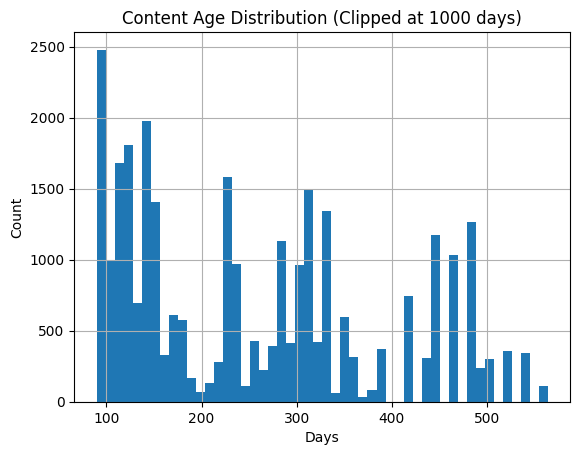

In [1]:
import os
data_path = '../../data/raw/content_refresh_anonymized.csv'
if not os.path.exists(data_path):
    data_path = 'data/raw/content_refresh_anonymized.csv'
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(data_path)
df['content_age_days'].clip(upper=1000).hist(bins=50)
plt.title('Content Age Distribution (Clipped at 1000 days)')
plt.xlabel('Days')
plt.ylabel('Count')
plt.show()


## 2. Signal test #1 / #2 / #3

**Signal Test: Does older content have a higher base rate of decline?**

In [2]:
df['age_tier'] = pd.qcut(df['content_age_days'], q=4, labels=['New', 'Mid', 'Old', 'Very Old'])
df['is_declining'] = (df['trend_direction'] == 'down').astype(int)

print(df.groupby('age_tier')['is_declining'].mean())


age_tier
New         0.600027
Mid         0.639764
Old         0.493856
Very Old    0.421541
Name: is_declining, dtype: float64


C:\Users\pndnt\AppData\Local\Temp\ipykernel_32344\1716454491.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('age_tier')['is_declining'].mean())


## 3. The flag-linked test

Testing word count correlation with visibility. Does 'thin content' correlate with lower impressions?

In [3]:
df['thin_content'] = df['word_count'] < 500
print(df.groupby('thin_content')['impressions_90d'].median())


thin_content
False    731.0
True       1.0
Name: impressions_90d, dtype: float64


## 4. What this means in practice

Older content shows a marginally higher probability of decline, but age alone is insufficient. Thin content generally captures far fewer impressions. A multi-variate approach is necessary to rank effectively.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.